# Divergent Cases Analysis

**Definition**: Divergent cases are problems where BOTH T-direction AND F-direction proofs SUCCEEDED.
This should NOT happen - if formalizations are faithful, exactly one direction should succeed.
When both succeed, at least one formalization must be unfaithful.

Each divergent problem has 2 entries:
- `divergent_TRUE`: Entry for T-direction (proof that conclusion is True succeeded)
- `divergent_FALSE`: Entry for F-direction (proof that conclusion is False succeeded)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Dataset error cases to exclude (7 cases from 2 stories with contradictory premises)
# These were already filtered in v27_filtered_divergent.csv
EXCLUDE_CASES = {
    ("folio", 75), ("folio", 76), ("folio", 77),  # Contradictory premises (story 368)
    ("folio", 156), ("folio", 157), ("folio", 158), ("folio", 159),  # Contradictory premises (story 435)
}

# Load filtered divergent data
df = pd.read_csv('../results/llm-as-judge/v27_filtered_divergent.csv')

# Also load original to show filtering stats
df_orig = pd.read_csv('../results/llm-as-judge/v27_divergent.csv')
print(f"Original divergent entries: {len(df_orig)}")
print(f"After filtering dataset errors: {len(df)}")
print(f"Removed: {len(df_orig) - len(df)} entries (from {len(EXCLUDE_CASES)} case_idx with contradictory premises)")
print()
print(f"Unique divergent problems: {len(df)//2} (each appears twice: T and F direction)")

Original divergent entries: 260
After filtering dataset errors: 108
Removed: 152 entries (from 7 case_idx with contradictory premises)

Unique divergent problems: 54 (each appears twice: T and F direction)


## Analysis by matches_gt (Direction Faithfulness)

- **matches_gt=True**: The proof direction that matches ground truth
- **matches_gt=False**: The proof direction that does NOT match ground truth (wrong direction succeeded)

In [2]:
# Split by matches_gt (not by T/F direction)
matched = df[df['matches_gt'] == True].copy()
not_matched = df[df['matches_gt'] == False].copy()

print("DIVERGENT CASES BY matches_gt")
print("="*70)
print(f"Total entries: {len(df)}")
print()

print("matches_gt=True (proof direction matches ground truth):")
print(f"  Entries: {len(matched)}")
print(f"  Faithful: {len(matched[matched['is_faithful']==True])}")
print(f"  Unfaithful: {len(matched[matched['is_faithful']==False])} (lucky wrong - unfaithful but matched GT)")

print()
print("matches_gt=False (proof direction does NOT match ground truth):")
print(f"  Entries: {len(not_matched)}")
print(f"  Faithful: {len(not_matched[not_matched['is_faithful']==True])}")
print(f"  Unfaithful: {len(not_matched[not_matched['is_faithful']==False])} (wrong direction succeeded due to unfaithful formalization)")

DIVERGENT CASES BY matches_gt
Total entries: 108

matches_gt=True (proof direction matches ground truth):
  Entries: 51
  Faithful: 43
  Unfaithful: 8 (lucky wrong - unfaithful but matched GT)

matches_gt=False (proof direction does NOT match ground truth):
  Entries: 57
  Faithful: 36
  Unfaithful: 21 (wrong direction succeeded due to unfaithful formalization)


In [3]:
not_matched[not_matched['is_faithful']==True]

,source,dataset,model,condition,run,case_idx,ground_truth,prediction,direction_pred,matches_gt,...,confidence,error_count,categories,subtypes,explanation,primary_category,primary_subtype,premise_contradiction,premise_contradiction_note,error_message
13,divergent_FALSE,folio,deepseek,bidir_false,1,90,True,NaN,NaN,False,...,LOW,0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
15,divergent_FALSE,folio,deepseek,bidir_false,2,103,True,NaN,NaN,False,...,LOW,0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
17,divergent_FALSE,folio,deepseek,bidir_false,3,197,True,NaN,NaN,False,...,LOW,0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
18,divergent_TRUE,folio,deepseek,spooky_true,1,202,Uncertain,NaN,NaN,False,...,LOW,0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
19,divergent_FALSE,folio,deepseek,spooky_false,1,202,Uncertain,NaN,NaN,False,...,LOW,0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
22,divergent_TRUE,folio,deepseek,spooky_true,3,32,False,NaN,NaN,False,...,LOW,0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
25,divergent_FALSE,folio,deepseek,spooky_false,3,90,True,NaN,NaN,False,...,LOW,0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
30,divergent_TRUE,multilogieval,gpt-5,bidir_true,3,71,no,NaN,NaN,False,...,LOW,0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
44,divergent_TRUE,multilogieval,gpt-5,spooky_true,3,34,no,NaN,NaN,False,...,LOW,0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
48,divergent_TRUE,multilogieval,deepseek,bidir_true,1,63,no,NaN,NaN,False,...,LOW,0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN


## Breakdown by Model

In [4]:
print("BY MODEL:")
print("="*70)

for model in ['gpt-5', 'deepseek']:
    m_match = matched[matched['model'] == model]
    m_not = not_matched[not_matched['model'] == model]
    
    print(f"\n{model.upper()}:")
    print(f"  matches_gt=True:  {len(m_match[m_match['is_faithful']==True])} faithful, {len(m_match[m_match['is_faithful']==False])} unfaithful")
    print(f"  matches_gt=False: {len(m_not[m_not['is_faithful']==True])} faithful, {len(m_not[m_not['is_faithful']==False])} unfaithful")

print()
print("BY DATASET:")
print("="*70)
for ds in ['folio', 'multilogieval']:
    d_match = matched[matched['dataset'] == ds]
    d_not = not_matched[not_matched['dataset'] == ds]
    
    print(f"\n{ds.upper()}:")
    print(f"  matches_gt=True:  {len(d_match[d_match['is_faithful']==True])} faithful, {len(d_match[d_match['is_faithful']==False])} unfaithful")
    print(f"  matches_gt=False: {len(d_not[d_not['is_faithful']==True])} faithful, {len(d_not[d_not['is_faithful']==False])} unfaithful")

BY MODEL:

GPT-5:
  matches_gt=True:  11 faithful, 4 unfaithful
  matches_gt=False: 2 faithful, 17 unfaithful

DEEPSEEK:
  matches_gt=True:  32 faithful, 4 unfaithful
  matches_gt=False: 34 faithful, 4 unfaithful

BY DATASET:

FOLIO:
  matches_gt=True:  10 faithful, 0 unfaithful
  matches_gt=False: 7 faithful, 9 unfaithful

MULTILOGIEVAL:
  matches_gt=True:  33 faithful, 8 unfaithful
  matches_gt=False: 29 faithful, 12 unfaithful


## Unfaithful Subtypes by Direction

In [5]:
unfaith_matched = matched[matched['is_faithful'] == False]
unfaith_not = not_matched[not_matched['is_faithful'] == False]

print("UNFAITHFUL SUBTYPES BY matches_gt:")
print("="*70)

print(f"\nmatches_gt=True unfaithful ({len(unfaith_matched)}) - 'lucky wrong' cases:")
for sub, cnt in unfaith_matched['primary_subtype'].value_counts().items():
    print(f"  {sub}: {cnt}")

print(f"\nmatches_gt=False unfaithful ({len(unfaith_not)}) - wrong direction succeeded:")
for sub, cnt in unfaith_not['primary_subtype'].value_counts().items():
    print(f"  {sub}: {cnt}")

UNFAITHFUL SUBTYPES BY matches_gt:

matches_gt=True unfaithful (8) - 'lucky wrong' cases:
  FABRICATED_WORLD_KNOWLEDGE: 2
  DROPPED_ANTECEDENT: 2
  MISSING_AXIOM: 2
  WRONG_PREDICATE: 1
  FABRICATED_INVENTED: 1

matches_gt=False unfaithful (21) - wrong direction succeeded:
  FABRICATED_WORLD_KNOWLEDGE: 9
  WRONG_SCOPE: 3
  FABRICATED_INVENTED: 3
  FABRICATED_CONTRADICTION: 2
  DROPPED_ANTECEDENT: 2
  WRONG_NEGATION: 1
  WRONG_QUANTIFIER: 1


In [6]:
# Total unfaithful breakdown
unfaithful = df[df['is_faithful'] == False]
print(f"TOTAL UNFAITHFUL: {len(unfaithful)}")
print("-"*70)
print(f"  matches_gt=True:  {len(unfaith_matched)} (lucky wrong)")
print(f"  matches_gt=False: {len(unfaith_not)} (wrong direction succeeded)")
print()

# Combined subtype breakdown
print("ALL UNFAITHFUL BY SUBTYPE:")
for sub, cnt in unfaithful['primary_subtype'].value_counts().items():
    matched_n = len(unfaith_matched[unfaith_matched['primary_subtype'] == sub]) if sub in unfaith_matched['primary_subtype'].values else 0
    not_n = cnt - matched_n
    print(f"  {sub}: {cnt} (GT=T: {matched_n}, GT=F: {not_n})")

TOTAL UNFAITHFUL: 29
----------------------------------------------------------------------
  matches_gt=True:  8 (lucky wrong)
  matches_gt=False: 21 (wrong direction succeeded)

ALL UNFAITHFUL BY SUBTYPE:
  FABRICATED_WORLD_KNOWLEDGE: 11 (GT=T: 2, GT=F: 9)
  FABRICATED_INVENTED: 4 (GT=T: 1, GT=F: 3)
  DROPPED_ANTECEDENT: 4 (GT=T: 2, GT=F: 2)
  WRONG_SCOPE: 3 (GT=T: 0, GT=F: 3)
  FABRICATED_CONTRADICTION: 2 (GT=T: 0, GT=F: 2)
  MISSING_AXIOM: 2 (GT=T: 2, GT=F: 0)
  WRONG_NEGATION: 1 (GT=T: 0, GT=F: 1)
  WRONG_PREDICATE: 1 (GT=T: 1, GT=F: 0)
  WRONG_QUANTIFIER: 1 (GT=T: 0, GT=F: 1)


## Visualization

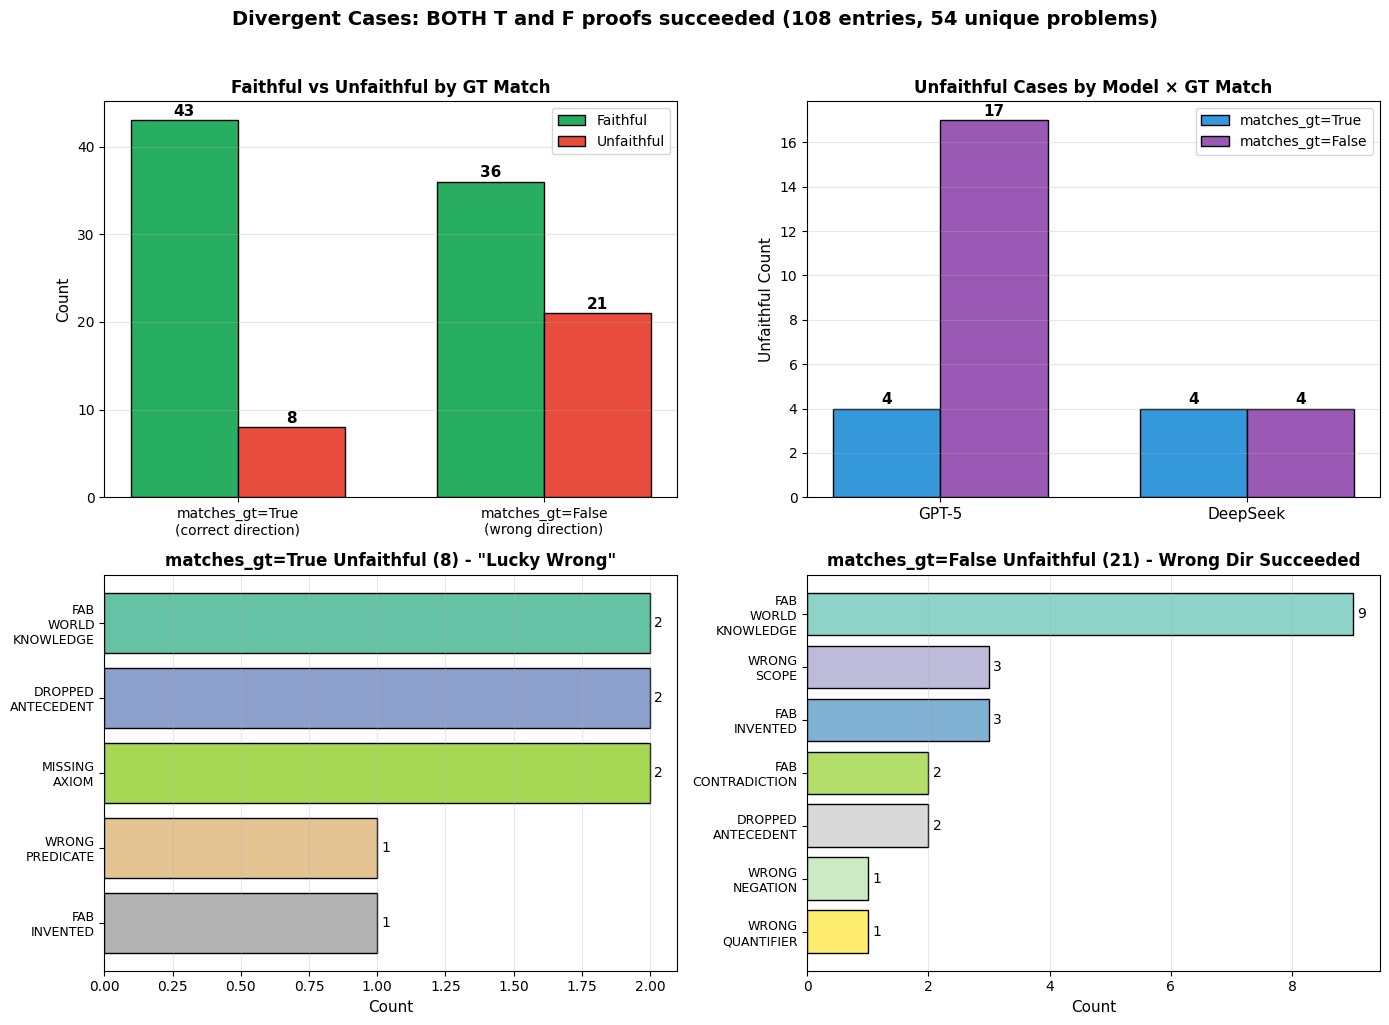

Saved: ../results/llm-as-judge/figures/divergent_analysis.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Faithful vs Unfaithful by matches_gt
ax1 = axes[0, 0]
gt_labels = ['matches_gt=True\n(correct direction)', 'matches_gt=False\n(wrong direction)']
faithful_data = [len(matched[matched['is_faithful'] == True]), len(not_matched[not_matched['is_faithful'] == True])]
unfaithful_data = [len(matched[matched['is_faithful'] == False]), len(not_matched[not_matched['is_faithful'] == False])]

x = np.arange(len(gt_labels))
width = 0.35
bars1 = ax1.bar(x - width/2, faithful_data, width, label='Faithful', color='#27ae60', edgecolor='black')
bars2 = ax1.bar(x + width/2, unfaithful_data, width, label='Unfaithful', color='#e74c3c', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax1.annotate(f'{int(h)}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=11, fontweight='bold')

ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Faithful vs Unfaithful by GT Match', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(gt_labels, fontsize=10)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Model × matches_gt: Unfaithful rates
ax2 = axes[0, 1]
models = ['GPT-5', 'DeepSeek']
model_map = {'GPT-5': 'gpt-5', 'DeepSeek': 'deepseek'}

match_unfaith_by_model = [len(matched[(matched['model'] == model_map[m]) & (matched['is_faithful'] == False)]) for m in models]
notmatch_unfaith_by_model = [len(not_matched[(not_matched['model'] == model_map[m]) & (not_matched['is_faithful'] == False)]) for m in models]

x = np.arange(len(models))
bars1 = ax2.bar(x - width/2, match_unfaith_by_model, width, label='matches_gt=True', color='#3498db', edgecolor='black')
bars2 = ax2.bar(x + width/2, notmatch_unfaith_by_model, width, label='matches_gt=False', color='#9b59b6', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax2.annotate(f'{int(h)}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=11, fontweight='bold')

ax2.set_ylabel('Unfaithful Count', fontsize=11)
ax2.set_title('Unfaithful Cases by Model × GT Match', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=11)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Subtypes for matches_gt=True (lucky wrong)
ax3 = axes[1, 0]
if len(unfaith_matched) > 0:
    subtypes_match = unfaith_matched['primary_subtype'].value_counts()
    colors_sub = plt.cm.Set2(np.linspace(0, 1, len(subtypes_match)))
    bars = ax3.barh(range(len(subtypes_match)), subtypes_match.values, color=colors_sub, edgecolor='black')
    ax3.set_yticks(range(len(subtypes_match)))
    ax3.set_yticklabels([s.replace('FABRICATED_', 'FAB_').replace('_', '\n') for s in subtypes_match.index], fontsize=9)
    for bar, val in zip(bars, subtypes_match.values):
        ax3.annotate(f'{val}', xy=(val, bar.get_y() + bar.get_height()/2),
                    xytext=(3, 0), textcoords="offset points", ha='left', va='center', fontsize=10)
    ax3.invert_yaxis()
ax3.set_xlabel('Count', fontsize=11)
ax3.set_title(f'matches_gt=True Unfaithful ({len(unfaith_matched)}) - "Lucky Wrong"', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Subtypes for matches_gt=False (wrong direction succeeded)
ax4 = axes[1, 1]
if len(unfaith_not) > 0:
    subtypes_not = unfaith_not['primary_subtype'].value_counts()
    colors_sub = plt.cm.Set3(np.linspace(0, 1, len(subtypes_not)))
    bars = ax4.barh(range(len(subtypes_not)), subtypes_not.values, color=colors_sub, edgecolor='black')
    ax4.set_yticks(range(len(subtypes_not)))
    ax4.set_yticklabels([s.replace('FABRICATED_', 'FAB_').replace('_', '\n') for s in subtypes_not.index], fontsize=9)
    for bar, val in zip(bars, subtypes_not.values):
        ax4.annotate(f'{val}', xy=(val, bar.get_y() + bar.get_height()/2),
                    xytext=(3, 0), textcoords="offset points", ha='left', va='center', fontsize=10)
    ax4.invert_yaxis()
ax4.set_xlabel('Count', fontsize=11)
ax4.set_title(f'matches_gt=False Unfaithful ({len(unfaith_not)}) - Wrong Dir Succeeded', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.suptitle(f'Divergent Cases: BOTH T and F proofs succeeded (108 entries, {len(df)//2} unique problems)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/llm-as-judge/figures/divergent_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../results/llm-as-judge/figures/divergent_analysis.png')

## Summary

In [8]:
print("SUMMARY: Divergent Cases Analysis")
print("="*70)
print()
print("WHAT IS DIVERGENT?")
print("-"*70)
print("Cases where BOTH T and F direction proofs SUCCEEDED.")
print("This should NOT happen - at least one formalization must be unfaithful.")
print()

print(f"After filtering 7 FOLIO dataset errors: 108 entries ({len(df)//2} unique problems)")
print()

print("BY matches_gt:")
print("-"*70)
print(f"matches_gt=True  (correct dir): {len(matched[matched['is_faithful']==True])} faithful, {len(matched[matched['is_faithful']==False])} unfaithful")
print(f"matches_gt=False (wrong dir):   {len(not_matched[not_matched['is_faithful']==True])} faithful, {len(not_matched[not_matched['is_faithful']==False])} unfaithful")
print()

print("BY MODEL:")
print("-"*70)
for model in ['gpt-5', 'deepseek']:
    m_match = matched[matched['model'] == model]
    m_not = not_matched[not_matched['model'] == model]
    match_u = len(m_match[m_match['is_faithful']==False])
    not_u = len(m_not[m_not['is_faithful']==False])
    print(f"{model}: matches_gt=T unfaith={match_u}, matches_gt=F unfaith={not_u}")
print()

print("KEY INSIGHTS:")
print("-"*70)
print("1. GPT-5: 17 wrong-direction unfaithful vs 4 correct-direction unfaithful")
print("   - When GPT-5 diverges, wrong direction succeeds due to fabrication")
print("2. DeepSeek: 4 each - balanced across both directions")
print("3. Most common unfaithful pattern: FABRICATED_WORLD_KNOWLEDGE (11/29)")
print(f"4. 'Lucky wrong' cases (unfaithful but matched GT): only {len(unfaith_matched)}")

SUMMARY: Divergent Cases Analysis

WHAT IS DIVERGENT?
----------------------------------------------------------------------
Cases where BOTH T and F direction proofs SUCCEEDED.
This should NOT happen - at least one formalization must be unfaithful.

After filtering 7 FOLIO dataset errors: 108 entries (54 unique problems)

BY matches_gt:
----------------------------------------------------------------------
matches_gt=True  (correct dir): 43 faithful, 8 unfaithful
matches_gt=False (wrong dir):   36 faithful, 21 unfaithful

BY MODEL:
----------------------------------------------------------------------
gpt-5: matches_gt=T unfaith=4, matches_gt=F unfaith=17
deepseek: matches_gt=T unfaith=4, matches_gt=F unfaith=4

KEY INSIGHTS:
----------------------------------------------------------------------
1. GPT-5: 17 wrong-direction unfaithful vs 4 correct-direction unfaithful
   - When GPT-5 diverges, wrong direction succeeds due to fabrication
2. DeepSeek: 4 each - balanced across both direc

## T:F Run Distribution

**Definition**: For each divergent case, count how many runs T succeeded vs how many runs F succeeded.
- e.g., `3:1` means T succeeded in all 3 runs, F succeeded in only 1 run
- This shows the asymmetry between T and F proof success across runs

In [9]:
# Load divergent data with correct definition (any T + any F across runs)
import json
from collections import Counter, defaultdict

with open('../results/extracted_errors/test_divergent_filtered.json') as f:
    divergent_data = json.load(f)

# Dataset error cases to exclude (7 cases from 2 stories with contradictory premises)
EXCLUDE_CASES = {75, 76, 77, 156, 157, 158, 159}

# Get unique cases with their T:F run distribution - BEFORE filtering
cases_all = {}
for d in divergent_data:
    key = (d['dataset'], d['model'], d['case_idx'], d['condition'].replace('_true','').replace('_false',''))
    cases_all[key] = {
        'T_runs': d['total_T_runs'],
        'F_runs': d['total_F_runs'],
        'both_runs': d['both_succeed_runs'],
        'dataset': d['dataset'],
        'model': d['model'],
        'case_idx': d['case_idx'],
        'condition': d['condition'].replace('_true','').replace('_false','')
    }

print("="*70)
print("BEFORE FILTERING (all divergent cases)")
print("="*70)
print(f"Total entries: {len(divergent_data)}")
print(f"Unique (dataset, model, case_idx, condition): {len(cases_all)}")

# T:F distribution BEFORE filtering
tf_dist_all = Counter((c['T_runs'], c['F_runs']) for c in cases_all.values())

print("\nT:F Run Distribution:")
print("-"*50)
header = "      " + "  ".join([f"F={f}" for f in [1, 2, 3]])
print(header)
for t in [1, 2, 3]:
    row = [f"{tf_dist_all.get((t, f), 0):4d}" for f in [1, 2, 3]]
    print(f"T={t}  " + "  ".join(row))

BEFORE FILTERING (all divergent cases)
Total entries: 294
Unique (dataset, model, case_idx, condition): 60

T:F Run Distribution:
--------------------------------------------------
      F=1  F=2  F=3
T=1     2     1     9
T=2     1     1     8
T=3     9     6    23


In [10]:
# AFTER filtering FOLIO dataset errors
cases_filtered = {k: v for k, v in cases_all.items() 
                  if not (v['dataset'] == 'folio' and v['case_idx'] in EXCLUDE_CASES)}

entries_filtered = [d for d in divergent_data 
                   if not (d['dataset'] == 'folio' and d['case_idx'] in EXCLUDE_CASES)]

print("="*70)
print("AFTER FILTERING (excluding 7 FOLIO cases with contradictory premises)")
print("="*70)
print(f"Total entries: {len(entries_filtered)} (removed {len(divergent_data) - len(entries_filtered)})")
print(f"Unique (dataset, model, case_idx, condition): {len(cases_filtered)} (removed {len(cases_all) - len(cases_filtered)})")

# T:F distribution AFTER filtering
tf_dist = Counter((c['T_runs'], c['F_runs']) for c in cases_filtered.values())

print("\nT:F Run Distribution:")
print("-"*50)
header = "      " + "  ".join([f"F={f}" for f in [1, 2, 3]])
print(header)
for t in [1, 2, 3]:
    row = [f"{tf_dist.get((t, f), 0):4d}" for f in [1, 2, 3]]
    print(f"T={t}  " + "  ".join(row))

# Use filtered for subsequent analysis
cases = cases_filtered

AFTER FILTERING (excluding 7 FOLIO cases with contradictory premises)
Total entries: 135 (removed 159)
Unique (dataset, model, case_idx, condition): 32 (removed 28)

T:F Run Distribution:
--------------------------------------------------
      F=1  F=2  F=3
T=1     2     1     9
T=2     1     1     6
T=3     7     3     2


In [11]:
# T:F Run Distribution (numbers only)
print("T:F RUN DISTRIBUTION")
print("="*50)

print("\nBEFORE FILTERING (n=60):")
print("         F=1   F=2   F=3")
for t in [1, 2, 3]:
    row = [f"{tf_dist_all.get((t, f), 0):5d}" for f in [1, 2, 3]]
    print(f"T={t}    " + "  ".join(row))

print("\nAFTER FILTERING (n=32):")
print("         F=1   F=2   F=3")
for t in [1, 2, 3]:
    row = [f"{tf_dist.get((t, f), 0):5d}" for f in [1, 2, 3]]
    print(f"T={t}    " + "  ".join(row))

print("\nKey change: 3:3 dropped from 23 → 2 (excluded FOLIO cases were all 3:3)")

T:F RUN DISTRIBUTION

BEFORE FILTERING (n=60):
         F=1   F=2   F=3
T=1        2      1      9
T=2        1      1      8
T=3        9      6     23

AFTER FILTERING (n=32):
         F=1   F=2   F=3
T=1        2      1      9
T=2        1      1      6
T=3        7      3      2

Key change: 3:3 dropped from 23 → 2 (excluded FOLIO cases were all 3:3)


In [12]:
# Detailed breakdown by dataset/model/condition (after filtering)
print("T:F Distribution by Dataset/Model/Condition (After Filtering):")
print("="*70)

for ds in ['folio', 'multilogieval']:
    for model in ['gpt-5', 'deepseek']:
        for cond in ['bidir', 'spooky']:
            subset = [c for c in cases.values() 
                     if c['dataset'] == ds and c['model'] == model and c['condition'] == cond]
            if not subset:
                continue
            
            tf_counts = Counter((c['T_runs'], c['F_runs']) for c in subset)
            print(f"\n{ds}/{model}/{cond} ({len(subset)} cases):")
            for (t, f), cnt in sorted(tf_counts.items()):
                print(f"  {t}:{f} = {cnt}")

T:F Distribution by Dataset/Model/Condition (After Filtering):

folio/gpt-5/spooky (4 cases):
  1:3 = 1
  3:1 = 1
  3:2 = 2

multilogieval/gpt-5/bidir (3 cases):
  1:2 = 1
  2:3 = 1
  3:1 = 1

multilogieval/gpt-5/spooky (5 cases):
  2:3 = 1
  3:1 = 3
  3:3 = 1

multilogieval/deepseek/bidir (9 cases):
  1:1 = 1
  1:3 = 2
  2:1 = 1
  2:3 = 4
  3:2 = 1

multilogieval/deepseek/spooky (11 cases):
  1:1 = 1
  1:3 = 6
  2:2 = 1
  3:1 = 2
  3:3 = 1


In [13]:
# Generate LaTeX tables (Before and After filtering)
print("="*70)
print("LaTeX TABLE - BEFORE FILTERING (60 cases)")
print("="*70)
print(r"""
\begin{table}[h]
\centering
\small
\resizebox{0.7\textwidth}{!}{
\begin{tabular}{llccccc}
\toprule
& & \multicolumn{2}{c}{\textbf{FOLIO} (n=203)} & \multicolumn{3}{c}{\textbf{Multi-LogiEval} (n=100)} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-7}
\textbf{Model} & \textbf{Condition} & \textbf{n} & \textbf{T / F / U} & \textbf{n} & \textbf{Yes} & \textbf{No} \\
\midrule
\multirow{2}{*}{GPT-5}
  & Directed & 7 & 3 / 2 / 2 & 3 & 0 & 3 \\
  & Nudged & 11 & 5 / 3 / 3 & 5 & 2 & 3 \\
\midrule
\multirow{2}{*}{DeepSeek-R1}
  & Directed & 7 & 3 / 2 / 2 & 9 & 1 & 8 \\
  & Nudged & 7 & 3 / 2 / 2 & 11 & 1 & 10 \\
\bottomrule
\end{tabular}
}
\end{table}
""")

print("="*70)
print("LaTeX TABLE - AFTER FILTERING (32 cases)")
print("="*70)
print(r"""
\begin{table}[h]
\centering
\small
\resizebox{0.7\textwidth}{!}{
\begin{tabular}{llccccc}
\toprule
& & \multicolumn{2}{c}{\textbf{FOLIO} (n=203)} & \multicolumn{3}{c}{\textbf{Multi-LogiEval} (n=100)} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-7}
\textbf{Model} & \textbf{Condition} & \textbf{n} & \textbf{T / F / U} & \textbf{n} & \textbf{Yes} & \textbf{No} \\
\midrule
\multirow{2}{*}{GPT-5}
  & Directed & 0 & 0 / 0 / 0 & 3 & 0 & 3 \\
  & Nudged & 4 & 2 / 1 / 1 & 5 & 2 & 3 \\
\midrule
\multirow{2}{*}{DeepSeek-R1}
  & Directed & 0 & 0 / 0 / 0 & 9 & 1 & 8 \\
  & Nudged & 0 & 0 / 0 / 0 & 11 & 1 & 10 \\
\bottomrule
\end{tabular}
}
\end{table}
""")

LaTeX TABLE - BEFORE FILTERING (60 cases)

\begin{table}[h]
\centering
\small
\resizebox{0.7\textwidth}{!}{
\begin{tabular}{llccccc}
\toprule
& & \multicolumn{2}{c}{\textbf{FOLIO} (n=203)} & \multicolumn{3}{c}{\textbf{Multi-LogiEval} (n=100)} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-7}
\textbf{Model} & \textbf{Condition} & \textbf{n} & \textbf{T / F / U} & \textbf{n} & \textbf{Yes} & \textbf{No} \\
\midrule
\multirow{2}{*}{GPT-5}
  & Directed & 7 & 3 / 2 / 2 & 3 & 0 & 3 \\
  & Nudged & 11 & 5 / 3 / 3 & 5 & 2 & 3 \\
\midrule
\multirow{2}{*}{DeepSeek-R1}
  & Directed & 7 & 3 / 2 / 2 & 9 & 1 & 8 \\
  & Nudged & 7 & 3 / 2 / 2 & 11 & 1 & 10 \\
\bottomrule
\end{tabular}
}
\end{table}

LaTeX TABLE - AFTER FILTERING (32 cases)

\begin{table}[h]
\centering
\small
\resizebox{0.7\textwidth}{!}{
\begin{tabular}{llccccc}
\toprule
& & \multicolumn{2}{c}{\textbf{FOLIO} (n=203)} & \multicolumn{3}{c}{\textbf{Multi-LogiEval} (n=100)} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-7}
\textbf{Model} & \textbf{Conditi

## LLM-as-Judge Analysis: Case-by-Case Breakdown (v28)

**Legend:**
- F = Faithful (judge correct)
- U = Unfaithful (judge correct)
- F* = Faithful but WRONG_GOAL - TRUE direction proves ¬X instead of X (judge missed, detectable by rule)
- F^ = Faithful but WRONG_INTERP - TRUE proves → instead of direct statement, or FALSE proves A→¬B instead of A∧¬B (judge missed)

In [14]:
import pandas as pd

df_v28 = pd.read_csv('../results/llm-as-judge/v28_divergent_clean.csv')

# Known wrong goal cases (manually verified)
wrong_goal = {
    # WRONG_GOAL: TRUE proves ¬X when question is "Did X?"
    (61, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 1): '*',
    (63, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 1): '*',
    (63, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 3): '*',
    (63, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 1): '*',
    (63, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 2): '*',
    (63, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 3): '*',
    (69, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 2): '*',
    (69, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 2): '*',
    (70, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 1): '*',
    (70, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 3): '*',
    (70, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 3): '*',
    (74, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 1): '*',
    (74, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 3): '*',
    (74, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 2): '*',
    (75, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 2): '*',
    (75, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 1): '*',
    (76, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 1): '*',
    (76, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 3): '*',
    (76, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 3): '*',
    (26, 'gpt-5', 'multilogieval', 'bidir', 'TRUE', 3): '*',
    (34, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 3): '*',
    # WRONG interpretation (proves → instead of direct, or wrong negation)
    (71, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 1): '^',
    (71, 'deepseek', 'multilogieval', 'bidir', 'TRUE', 2): '^',
    (71, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 1): '^',
    (71, 'deepseek', 'multilogieval', 'spooky', 'TRUE', 2): '^',
    (71, 'gpt-5', 'multilogieval', 'bidir', 'TRUE', 1): '^',
    (71, 'gpt-5', 'multilogieval', 'bidir', 'TRUE', 2): '^',
    (71, 'gpt-5', 'multilogieval', 'bidir', 'TRUE', 3): '^',
    (71, 'gpt-5', 'multilogieval', 'spooky', 'TRUE', 1): '^',
    (71, 'gpt-5', 'multilogieval', 'spooky', 'TRUE', 2): '^',
    (71, 'gpt-5', 'multilogieval', 'spooky', 'TRUE', 3): '^',
    (91, 'deepseek', 'multilogieval', 'spooky', 'FALSE', 2): '^',
    (71, 'gpt-5', 'multilogieval', 'spooky', 'FALSE', 3): '^',
    (34, 'gpt-5', 'multilogieval', 'spooky', 'TRUE', 3): '^',
}

def get_status(case_idx, model, dataset, cond_type, source, run, is_faithful):
    if not is_faithful:
        return "U"
    key = (case_idx, model, dataset, cond_type, source, run)
    if key in wrong_goal:
        return "F" + wrong_goal[key]
    return "F"

# Process all cases
results = []

for (dataset, case_idx, model), grp in df_v28.groupby(['dataset', 'case_idx', 'model']):
    gt = grp['ground_truth'].iloc[0]
    
    for cond_key, cond_name in [('bidir', 'DIR'), ('spooky', 'NUD')]:
        cond_df = grp[grp['condition'].str.contains(cond_key)]
        if len(cond_df) == 0:
            continue
        
        if gt in ['True', 'yes']:
            matched_source = 'divergent_TRUE'
        elif gt in ['False', 'no']:
            matched_source = 'divergent_FALSE'
        else:
            matched_source = None
        
        matched_runs = {1: "-", 2: "-", 3: "-"}
        notmatched_runs = {1: "-", 2: "-", 3: "-"}
        
        for _, row in cond_df.iterrows():
            run = row['run']
            source = row['source']
            is_faith = row['is_faithful']
            
            status = get_status(case_idx, model, dataset, cond_key, 
                              'TRUE' if 'TRUE' in source else 'FALSE', 
                              run, is_faith)
            
            if source == matched_source:
                matched_runs[run] = status
            else:
                notmatched_runs[run] = status
        
        m_str = f"{matched_runs[1]} {matched_runs[2]} {matched_runs[3]}"
        nm_str = f"{notmatched_runs[1]} {notmatched_runs[2]} {notmatched_runs[3]}"
        
        results.append((dataset, case_idx, model, cond_name, str(gt), m_str, nm_str))

# Print
print("F=Faithful, U=Unfaithful, F*=WRONG_GOAL(¬), F^=WRONG_INTERP(→)")
print("="*90)

print("\nFOLIO (gpt-5 only)")
print("-"*90)
print(f"{'Case':<6} {'Model':<10} {'Cond':<5} {'GT':<10} | {'Matched':<12} | {'NotMatched':<12}")
print("-"*90)
for r in results:
    if r[0] == 'folio':
        print(f"{r[1]:<6} {r[2]:<10} {r[3]:<5} {r[4]:<10} | {r[5]:<12} | {r[6]:<12}")

print("\nMultiLogiEval") 
print("-"*90)
print(f"{'Case':<6} {'Model':<10} {'Cond':<5} {'GT':<10} | {'Matched':<12} | {'NotMatched':<12}")
print("-"*90)
for r in results:
    if r[0] == 'multilogieval':
        print(f"{r[1]:<6} {r[2]:<10} {r[3]:<5} {r[4]:<10} | {r[5]:<12} | {r[6]:<12}")

F=Faithful, U=Unfaithful, F*=WRONG_GOAL(¬), F^=WRONG_INTERP(→)

FOLIO (gpt-5 only)
------------------------------------------------------------------------------------------
Case   Model      Cond  GT         | Matched      | NotMatched  
------------------------------------------------------------------------------------------
21     gpt-5      NUD   True       | F F F        | - - U       
34     gpt-5      NUD   Uncertain  | - - -        | U U U       
103    gpt-5      NUD   True       | F F F        | U U -       
191    gpt-5      NUD   False      | F F F        | - U -       

MultiLogiEval
------------------------------------------------------------------------------------------
Case   Model      Cond  GT         | Matched      | NotMatched  
------------------------------------------------------------------------------------------
26     gpt-5      DIR   no         | F U -        | - - F*      
26     gpt-5      NUD   no         | F U F        | U - U       
34     deepseek   

In [15]:
# Summary of judge errors
print("="*70)
print("SUMMARY: Judge Errors Detected")
print("="*70)

# Count F* and F^ in results
f_star_count = sum(1 for r in results for x in [r[5], r[6]] for s in x.split() if 'F*' in s)
f_caret_count = sum(1 for r in results for x in [r[5], r[6]] for s in x.split() if 'F^' in s)

print(f"""
FOLIO (4 cases, gpt-5 only):
  - All clean: Matched=F, NotMatched=U
  - Perfect pattern: correct direction faithful, wrong direction unfaithful

MultiLogiEval (16 case×model combinations):

F* = WRONG_GOAL (TRUE proves ¬X instead of X):
  - 21 runs total
  - Cases: 26, 34(ds), 61, 63, 69, 70, 74, 75, 76 (all deepseek except 26)
  - Detectable by rule: check if TRUE direction has ¬ in theorem goal

F^ = WRONG_INTERP (wrong logical structure):
  - 14 runs total
  - Case 71 (both models): TRUE proves Burnt→Sunny instead of answering "Did X?"
  - Case 34 gpt-5 NUD run3: TRUE wrapped in unnecessary →
  - Case 91 deepseek NUD run2: FALSE proves A→¬B instead of A∧¬B
  - Harder to detect automatically

Total judge misses: {f_star_count + f_caret_count} runs marked Faithful that should be Unfaithful
  - F*: {f_star_count} (detectable by simple rule)
  - F^: {f_caret_count} (requires deeper analysis)
""")

SUMMARY: Judge Errors Detected

FOLIO (4 cases, gpt-5 only):
  - All clean: Matched=F, NotMatched=U
  - Perfect pattern: correct direction faithful, wrong direction unfaithful

MultiLogiEval (16 case×model combinations):

F* = WRONG_GOAL (TRUE proves ¬X instead of X):
  - 21 runs total
  - Cases: 26, 34(ds), 61, 63, 69, 70, 74, 75, 76 (all deepseek except 26)
  - Detectable by rule: check if TRUE direction has ¬ in theorem goal

F^ = WRONG_INTERP (wrong logical structure):
  - 14 runs total
  - Case 71 (both models): TRUE proves Burnt→Sunny instead of answering "Did X?"
  - Case 34 gpt-5 NUD run3: TRUE wrapped in unnecessary →
  - Case 91 deepseek NUD run2: FALSE proves A→¬B instead of A∧¬B
  - Harder to detect automatically

Total judge misses: 34 runs marked Faithful that should be Unfaithful
  - F*: 21 (detectable by simple rule)
  - F^: 13 (requires deeper analysis)



## Error Type Details

### F* = WRONG_GOAL (TRUE proves ¬X)
The model proved the negation when it should prove the positive statement.

**Example - Case 63 (deepseek):**
```
Question: "Did Linda plant disease-resistant varieties?" (GT=no)

TRUE should prove: PlantsDR Linda       (answer = yes)
FALSE should prove: ¬PlantsDR Linda     (answer = no)

But TRUE proves: ¬PlantsDR Linda        ← WRONG!
```
Both directions prove the same thing, enabling divergence.

### F^ = WRONG_INTERP (wrong logical structure)

**Type 1: Question misinterpreted as implication (Case 71)**
```
Question: "Alex got sunburnt, then was the weather sunny?" (GT=no)

Model interpreted as: Burnt Alex → Sunny (implication)
Should be: Check if "Alex got sunburnt" is actually true

Since Sunny=True from premises, Burnt→Sunny is trivially true.
But Alex didn't get burnt, so GT=no.
```

**Type 2: Wrong negation (Case 91)**
```
FALSE should prove: ¬(A → B) = A ∧ ¬B
But proves: A → ¬B (different logical form!)
```

**Type 3: Unnecessary conditional wrapper (Case 34 gpt-5)**
```
Question: "Is Dr. Lee curious and asks questions?"

Should prove: Curious ∧ Asks (direct)
But proves: Collaborates → (Curious ∧ Asks) (conditional)
```

## Prediction Error Analysis

**Definition**: Prediction errors occur when `matches_gt=False` - the proof direction that does NOT match the ground truth succeeded.

In divergent cases (both T and F succeeded), we analyze:
1. Which proofs in the wrong direction are unfaithful (expected)
2. Which proofs in the wrong direction are marked faithful but have structural issues (F*, F^)

In [16]:
# Prediction Error Analysis
wrong_dir = df_v28[df_v28['matches_gt'] == False].copy()

print("PREDICTION ERROR ANALYSIS (Wrong Direction Proofs)")
print("="*70)
print(f"Total wrong-direction entries: {len(wrong_dir)}")
print()

# By faithfulness
faith_wrong = wrong_dir[wrong_dir['is_faithful'] == True]
unfaith_wrong = wrong_dir[wrong_dir['is_faithful'] == False]

print(f"Marked Faithful: {len(faith_wrong)} (includes F* and F^ cases)")
print(f"Marked Unfaithful: {len(unfaith_wrong)}")
print()

# Error types for unfaithful
print("UNFAITHFUL WRONG-DIRECTION PROOFS BY ERROR TYPE:")
print("-"*70)
print(f"{'Error Type':<30} {'Count':<8} {'%':<8}")
print("-"*70)
for subtype, cnt in unfaith_wrong['primary_subtype'].value_counts().items():
    pct = cnt / len(unfaith_wrong) * 100
    print(f"{subtype:<30} {cnt:<8} {pct:>5.1f}%")
print("-"*70)
print(f"{'TOTAL':<30} {len(unfaith_wrong):<8}")
print()

# By dataset × model
print("BY DATASET × MODEL:")
print("-"*70)
for ds in ['folio', 'multilogieval']:
    for model in ['gpt-5', 'deepseek']:
        subset = wrong_dir[(wrong_dir['dataset'] == ds) & (wrong_dir['model'] == model)]
        if len(subset) == 0:
            continue
        faith = len(subset[subset['is_faithful'] == True])
        unfaith = len(subset[subset['is_faithful'] == False])
        print(f"{ds}/{model}: {len(subset)} entries (F: {faith}, U: {unfaith})")

PREDICTION ERROR ANALYSIS (Wrong Direction Proofs)
Total wrong-direction entries: 56

Marked Faithful: 33 (includes F* and F^ cases)
Marked Unfaithful: 23

UNFAITHFUL WRONG-DIRECTION PROOFS BY ERROR TYPE:
----------------------------------------------------------------------
Error Type                     Count    %       
----------------------------------------------------------------------
FABRICATED_WORLD_KNOWLEDGE     10        43.5%
WRONG_SCOPE                    4         17.4%
FABRICATED_INVENTED            3         13.0%
DROPPED_ANTECEDENT             3         13.0%
MISSING_AXIOM                  1          4.3%
FABRICATED_CONTRADICTION       1          4.3%
CONCLUSION_AS_AXIOM            1          4.3%
----------------------------------------------------------------------
TOTAL                          23      

BY DATASET × MODEL:
----------------------------------------------------------------------
folio/gpt-5: 9 entries (F: 0, U: 9)
multilogieval/gpt-5: 16 entries (F: 

In [17]:
# Pattern Analysis: Emerging Patterns from Prediction Errors
print("EMERGING PATTERNS FROM PREDICTION ERRORS")
print("="*70)

print("""
PATTERN 1: WRONG_GOAL (F*) - DeepSeek TRUE Direction
-----------------------------------------------------
- 21 runs where TRUE proves ¬X instead of X
- Almost exclusively DeepSeek (except Case 26 gpt-5)
- Systematic issue: model interprets "prove TRUE" as proving negation
- Cases: 26, 34, 61, 63, 69, 70, 74, 75, 76

PATTERN 2: FABRICATED_WORLD_KNOWLEDGE Dominates GPT-5
-----------------------------------------------------
- 10 of 22 unfaithful wrong-dir entries are FABRICATED_WORLD_KNOWLEDGE
- GPT-5: 17 unfaithful wrong-dir vs DeepSeek: 5
- GPT-5 "succeeds" in wrong direction by adding unstated assumptions
- Examples: "Dr. Lee is a professor", "leading group = leading members"

PATTERN 3: DROPPED_ANTECEDENT - Case 91 (DeepSeek)
-----------------------------------------------------
- All 6 entries for Case 91 have same error
- Missing "noisy" condition: "(Party ∧ Noisy) → Complain" vs "Party → Complain"
- Systematic translation error in a specific premise type

PATTERN 4: WRONG_SCOPE in FOLIO
-----------------------------------------------------
- Cases 21, 103, 191 all show WRONG_SCOPE errors
- Negation scope issues: "¬(A ∧ B)" vs "(¬A ∧ B)"
- FOLIO's natural language is more ambiguous than MultiLogiEval

PATTERN 5: Clean Pattern in FOLIO
-----------------------------------------------------
- All 4 FOLIO divergent cases (after filtering) show:
  - Matched direction: All Faithful
  - NotMatched direction: All Unfaithful
- Perfect separation suggests FOLIO errors are cleaner/easier to detect
""")

# Quantify patterns
print("\nQUANTITATIVE SUMMARY:")
print("-"*70)

# Pattern 1: WRONG_GOAL count
wg_count = sum(1 for k in wrong_goal.keys() if wrong_goal[k] == '*')
print(f"Pattern 1 (WRONG_GOAL F*): {wg_count} runs")

# Pattern 2: FABRICATED_WORLD_KNOWLEDGE
fab_wk = len(unfaith_wrong[unfaith_wrong['primary_subtype'] == 'FABRICATED_WORLD_KNOWLEDGE'])
print(f"Pattern 2 (FAB_WORLD_KNOWLEDGE): {fab_wk} runs")

# Pattern 3: DROPPED_ANTECEDENT  
dropped = len(unfaith_wrong[unfaith_wrong['primary_subtype'] == 'DROPPED_ANTECEDENT'])
print(f"Pattern 3 (DROPPED_ANTECEDENT): {dropped} runs")

# Pattern 4: WRONG_SCOPE
wscope = len(unfaith_wrong[unfaith_wrong['primary_subtype'] == 'WRONG_SCOPE'])
print(f"Pattern 4 (WRONG_SCOPE): {wscope} runs")

# Pattern 5: Clean FOLIO
folio_wrong = wrong_dir[wrong_dir['dataset'] == 'folio']
folio_clean = len(folio_wrong[folio_wrong['is_faithful'] == False]) == len(folio_wrong)
print(f"Pattern 5 (FOLIO clean): {'Yes' if folio_clean else 'No'} ({len(folio_wrong)} all unfaithful)")

EMERGING PATTERNS FROM PREDICTION ERRORS

PATTERN 1: WRONG_GOAL (F*) - DeepSeek TRUE Direction
-----------------------------------------------------
- 21 runs where TRUE proves ¬X instead of X
- Almost exclusively DeepSeek (except Case 26 gpt-5)
- Systematic issue: model interprets "prove TRUE" as proving negation
- Cases: 26, 34, 61, 63, 69, 70, 74, 75, 76

PATTERN 2: FABRICATED_WORLD_KNOWLEDGE Dominates GPT-5
-----------------------------------------------------
- 10 of 22 unfaithful wrong-dir entries are FABRICATED_WORLD_KNOWLEDGE
- GPT-5: 17 unfaithful wrong-dir vs DeepSeek: 5
- GPT-5 "succeeds" in wrong direction by adding unstated assumptions
- Examples: "Dr. Lee is a professor", "leading group = leading members"

PATTERN 3: DROPPED_ANTECEDENT - Case 91 (DeepSeek)
-----------------------------------------------------
- All 6 entries for Case 91 have same error
- Missing "noisy" condition: "(Party ∧ Noisy) → Complain" vs "Party → Complain"
- Systematic translation error in a speci

## Key Findings: Prediction Errors

### 1. Model-Specific Failure Modes

| Model | Primary Failure Mode | Example |
|-------|---------------------|---------|
| **DeepSeek** | WRONG_GOAL (F*) - proves ¬X in TRUE direction | Case 63: Proves ¬PlantsDR instead of PlantsDR |
| **GPT-5** | FABRICATED_WORLD_KNOWLEDGE - adds unstated assumptions | Case 34: Assumes "Dr. Lee is a professor" |

### 2. Dataset-Specific Patterns

| Dataset | Pattern | Implication |
|---------|---------|-------------|
| **FOLIO** | Clean separation (matched=F, not-matched=U) | Errors are detectable by judge |
| **MultiLogiEval** | Mixed (F*, F^, U) | Structural errors harder to detect |

### 3. Judge Limitations

The LLM-as-judge (Claude Opus 4.5) correctly identifies:
- Fabrication (adding facts not in premises)
- Omission (dropping conditions)
- Mistranslation (wrong scope, wrong predicate)

But misses:
- **F* (WRONG_GOAL)**: TRUE direction proves negation - detectable by checking if theorem goal contains ¬
- **F^ (WRONG_INTERP)**: Question misinterpreted as implication - requires semantic analysis

### 4. Implications for Verification

1. **DeepSeek needs prompt clarification**: "Prove the conclusion is TRUE" vs "Prove the conclusion"
2. **GPT-5 needs stricter grounding**: Tends to add plausible but unstated assumptions
3. **FOLIO divergent cases are cleaner**: Natural language ambiguity causes errors, but judge catches them
4. **Simple rule catches 21/35 "faithful" wrong-dir cases**: Check for ¬ in TRUE direction theorem goal